/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /
/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_24480/3621600417.py:226: RuntimeWarning: invalid value encountered in divide
  weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r


從 3D 立方體中提取了 11 個有效點。


Grid search:   0%|          | 0/100000 [00:00<?, ?it/s]

New best: 758.5 @ (0, 0, 0, 0, 0)
New best: 650.2 @ (0, 0, 9, 0, 0)
New best: 619.6 @ (0, 0, 9, 0, 1)
New best: 606 @ (0, 0, 9, 0, 2)
New best: 605.8 @ (0, 0, 9, 1, 2)
New best: 605.6 @ (0, 0, 9, 2, 2)
New best: 605.5 @ (0, 0, 9, 3, 2)
New best: 605.4 @ (0, 0, 9, 4, 2)
New best: 605.3 @ (0, 0, 9, 5, 2)
New best: 605.3 @ (0, 0, 9, 6, 2)
New best: 604.8 @ (0, 9, 0, 0, 0)
New best: 301.9 @ (1, 0, 0, 0, 0)
New best: 140.1 @ (1, 0, 9, 0, 0)
New best: 126.1 @ (1, 8, 0, 0, 5)
New best: 124.7 @ (1, 8, 0, 1, 5)
New best: 123.9 @ (1, 8, 0, 2, 5)
New best: 73.16 @ (1, 9, 0, 0, 2)
New best: 69.36 @ (4, 0, 0, 0, 1)
New best: 68.71 @ (4, 9, 2, 5, 1)
New best: 67.21 @ (4, 9, 2, 6, 1)
New best: 66.04 @ (4, 9, 2, 7, 1)
New best: 64.77 @ (4, 9, 2, 8, 1)
New best: 63.31 @ (4, 9, 2, 9, 1)
New best: 62.95 @ (5, 0, 0, 2, 1)
New best: 62.15 @ (7, 0, 2, 2, 1)
New best: 60.69 @ (7, 0, 2, 3, 1)
New best: 60.03 @ (7, 0, 2, 4, 1)
(10, 10, 10, 10, 10)
(7, 0, 2, 4, 1)
7 0 2 4
Theta = 65.45454545454545 deg
Phi = 0.0

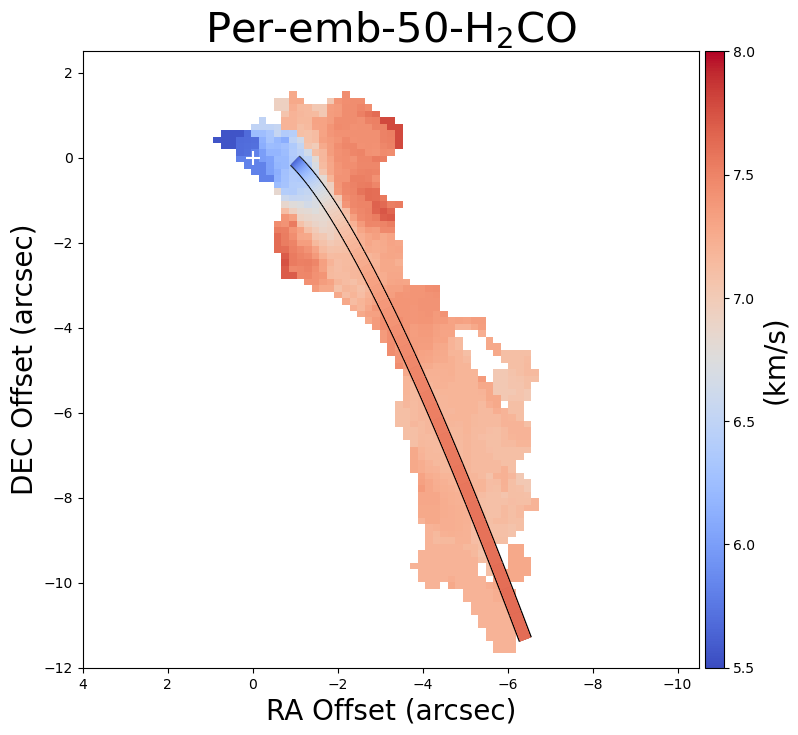

In [1]:
# 標準函式庫
import sys
import os
import warnings

# 第三方函式庫 (科學計算/優化)
import emcee
import numpy as np
import scipy.constants as spc
from scipy.interpolate import interp1d
from scipy.optimize import fsolve # 假設你需要 fsolve

# 天文學/數據處理函式庫
from astropy import units as u
from astropy.io import fits 
from astropy.wcs import WCS
from spectral_cube import SpectralCube

# 繪圖函式庫
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import corner
from tqdm.auto import tqdm
from itertools import product
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
import matplotlib as mpl
from scipy.stats import binned_statistic_2d, binned_statistic # 引入 2D 統計工具

# 專案本地模組
import PSSpy as pss

Local_Standard_Velocity = 7.5 #km/s
pa_deg = 170 + 90
pa_rad = pa_deg * np.pi / 180
ra_start = '03:29:06.360'
ra_end = '03:29:08.293'
dec_deg = 31 + 21/60 + 57.1280/3600  # +31.21.38.180 => 31.3606 度
distance_pc = 300
n_pixels = 163
M_SUN_KG = 1.98847e30  # kg

radius_in_au, radius_out_au = 2.4e2, 3.8e3

cube = SpectralCube.read('Per-emb-50_CD_l021l060_uvsub_H2CO_multi_small_fitcube.fits')
header = fits.getheader('Per-emb-50_CD_l021l060_uvsub_H2CO_multi_small_fitcube.fits')

im_center = int(header['CRPIX2']), int(header['CRPIX1'])  # (z, x)
dx = abs(header['CDELT2']) * 3600  # arcsec per pixel
dx_au = dx * distance_pc
v0 = header['CRVAL3']          # reference velocity
dv = abs(header['CDELT3'])      # km/s per channel
v_lastch_vel = 4.0984
v_lastch_num = 70

# Subcube and moment calculation
velocity_range = [10.0236, 4.0984] * u.km / u.s  # Adjusted velocity range
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
rms_channel = 3.521605434804e-1
# rms_mom0 = 5.134089023394e-2
cube_shape = subcube.shape  # (n_channels, n_z, n_x)

hdu_mom0 = fits.PrimaryHDU(data=moment0, header=header)
hdu_mom0.writeto('Per-emb-50_H2CO_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=moment1.data, header=header)
hdu_mom1.header['BUNIT'] = 'km/s'
hdu_mom1.writeto('Per-emb-50_H2CO_mom1.fits', overwrite=True)

v_weight_pix = (dv / dx) ** 2  
v_weight_phys = (dv / dx_au) ** 2  
v_weight_phys *= 20
max_dist_value = 30
radius_ref_au = 240 #Disk edge (au)
M_star = 2.58
Omega_ref = pss.Omega_ref(radius_ref_au, M_star) #Keplerian velocity (radian)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
t_ff_seconds = 1.0 / Omega_ref
t_ff_Myr = t_ff_seconds / (1e6 * spc.year)
scale = 'log'
log_power = 1.5

ny, nx = moment0.shape
radius = 4
mask_pos = [108, 67]       

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

ny, nx = moment0.shape
radius = 4
mask_pos = [121, 64]

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = masked_center_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

ny, nx = moment0.shape
radius = 4
mask_pos = [103, 72]

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = masked_center_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

ny, nx = moment0.shape
radius = 4
mask_pos = [114, 66]

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = masked_center_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

ny, nx = moment0.shape
radius = 4
mask_pos = [94, 84]

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = masked_center_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

ny, nx = moment0.shape
radius = 5
mask_pos = [99, 79]

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], cube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = masked_center_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

find_x = np.array([0, 5, 8, 10, 13, 21, 28])
find_y = np.array([0, -4, -10, -16, -20, -32, -54])
find_r, find_theta = pss.spherical_coords(find_x, find_y)
find_streaml = interp1d(find_r, find_theta, fill_value="extrapolate")

# cube_data = cube.filled_data[:].value  # shape = (v, z, x)
maskcent_cube_data = masked_center_cube.filled_data[:].value  # shape = (v, z, x)

init_points = [(34, im_center[0], im_center[1]),
                (34, 121, 50),
                (34, 115, 53),
                (34, 109, 55),
                (34, 105, 58),
                (34, 93, 66),
                (34, 71, 73)]  # (v, z, x) coordinates of initial points
# stream_mask = pss.grow_region(cube_data, init_points, rms_channel, sigma_thresh=3, max_iter=1000)
maskcent_stream_mask = pss.grow_region(maskcent_cube_data, init_points, rms_channel, sigma_thresh=3, max_iter=1000)

# masked_cube_ori = cube.with_mask(stream_mask)
# new_cube_data = masked_cube_ori.filled_data[:].value
masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)
new_cube_data = masked_cube.filled_data[:].value
masked_cube = masked_cube.with_fill_value(0)

# str_moment0 = masked_cube_ori.moment(order=0).value
# str_moment1 = masked_cube_ori.moment(order=1).value
str_moment0 = masked_cube.moment(order=0).value
str_moment1 = masked_cube.moment(order=1).value

hdu_mom0 = fits.PrimaryHDU(data=str_moment0, header=header)
hdu_mom0.writeto('Per-emb-50_H2CO_streamer_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=str_moment1, header=header)
hdu_mom1.writeto('Per-emb-50_H2CO_streamer_mom1.fits', overwrite=True)

# -----------------------------------------------------------------------
# 1. 建立 3D 座標網格
# -----------------------------------------------------------------------
# 這裡 v, z, x 是像素編號，與 cube_shape (v, z, x) 順序一致
v, z, x = np.indices(cube_shape)
# 相對於參考像素的座標
x_rel = x - im_center[1]
z_rel = z - im_center[0]

# 計算每個體素的球座標 (r, theta)
# r, theta 會是 3D 陣列，與 data_cube 相同維度
r, theta = pss.spherical_coords(x_rel, z_rel)

N_elements = 11
pars = np.linspace(0.07, 67, N_elements + 1)  # 徑向距離區間

x_means = np.zeros(N_elements)
z_means = np.zeros(N_elements)
v_means = np.zeros(N_elements)
xzstd = np.zeros(N_elements)

x_array_list = []
z_array_list = []
v_array_list = []
weights_list = []

# -----------------------------------------------------------------------
# 2. 找到每個徑向區間的 xz 平均座標
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_streaml = (pars[i] + pars[i+1]) / 2
    theta0 = find_streaml(r_streaml)

    # 計算 3D 權重陣列
    weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
    # 處理 r=0 的情況
    weight_theta[r==0] = 0
    weight_theta[weight_theta < 0.99] = 0

    # 找出指定徑向範圍和有效數據的體素
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (new_cube_data > 0)
    
    if np.sum(dinds) > 0:
        # 計算加權平均
        x_means[i] = np.average(x_rel[dinds], weights=new_cube_data[dinds] * weight_theta[dinds])
        z_means[i] = np.average(z_rel[dinds], weights=new_cube_data[dinds] * weight_theta[dinds])
        
        # 計算加權標準差
        xzstd[i] = np.sqrt(np.average((x_rel[dinds] - x_means[i]) ** 2 + (z_rel[dinds] - z_means[i]) ** 2, weights=new_cube_data[dinds] * weight_theta[dinds]))
    else:
        # 如果該區間沒有有效數據，賦予 NaN
        x_means[i] = np.nan
        z_means[i] = np.nan
        xzstd[i] = np.nan


# -----------------------------------------------------------------------
# 3. 創建內插函數，用於計算高斯權重
# -----------------------------------------------------------------------
# 篩選掉 NaN 值，確保內插函數正確
valid_means_mask = np.isfinite(x_means)
if np.sum(valid_means_mask) < 2:
    print("數據太稀疏，無法建立內插函數，請檢查數據或參數")
    # 返回一個空的陣列或直接退出
    streamercom_v_pix = np.array([])
    streamercom_z_pix = np.array([])
    streamercom_x_pix = np.array([])
else:
    r_means, theta_means = pss.spherical_coords(x_means[valid_means_mask], z_means[valid_means_mask])
    theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False)
    std_r = interp1d(r_means, xzstd[valid_means_mask], fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)

# -----------------------------------------------------------------------
# 4. 計算 v, z, x 的加權平均
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_ref = (pars[i] + pars[i+1]) / 2
    
    # 如果徑向區間無效，直接跳過
    if not np.isfinite(x_means[i]):
        x_means[i] = np.nan
        z_means[i] = np.nan
        v_means[i] = np.nan
        continue
        
    theta_ref = theta_r(r_ref)
    std_ref = std_r(r_ref) / r_ref
    
    # 計算 3D 高斯權重
    delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
    weights = new_cube_data * pss.gaussian(delta_theta, 0, std_ref)
    
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (new_cube_data > 0)

    # 存儲每次迴圈的值
    x_array_list.append(x_rel[dinds])
    z_array_list.append(z_rel[dinds])
    v_array_list.append(v[dinds])
    
    # 計算加權平均
    x_means[i] = np.average(x_rel[dinds], weights=weights[dinds])  
    z_means[i] = np.average(z_rel[dinds], weights=weights[dinds])
    v_means[i] = np.average(v[dinds], weights=weights[dinds])

# 5. 準備擬合所需的數據
streamercom_v_pix = np.array(v_means) 
streamercom_z_pix = np.array(z_means)
streamercom_x_pix = np.array(x_means)

x_rotated = streamercom_x_pix * np.cos(pa_rad) + streamercom_z_pix * np.sin(pa_rad)
z_rotated = -streamercom_x_pix * np.sin(pa_rad) + streamercom_z_pix * np.cos(pa_rad)

# 轉換為物理單位
streamercom_x_AU = x_rotated * dx_au
streamercom_z_AU = z_rotated * dx_au
streamercom_v_km = v_lastch_vel + (v_lastch_num - streamercom_v_pix) * dv
streamercom_v_LS_km = streamercom_v_km - Local_Standard_Velocity

print(f"從 3D 立方體中提取了 {np.sum(np.isfinite(x_means))} 個有效點。")

range_start_Myr = 40 * P_half_Myr  # 約 125.6 * t_ff
range_end_Myr   = 50 * P_half_Myr  # 約 157.0 * t_ff

n_theta, n_phi, n_Inclination, n_T_Myr, n_Omega = 10, 10, 10, 10, 10
theta = np.linspace(0, np.pi / 2, n_theta+2)[1:-1]  # `Theta` 的範圍 [0, π]
phi = np.linspace(0, 2*np.pi, n_phi, endpoint=False)  # `Phi` 的範圍 [0, 2π]
# T_Myr = np.linspace(40, 50, n_T_Myr) * np.pi / Omega_ref / 1e6 / spc.year# `Time` 的範圍 [1e-2, 1e-1]
T_Myr = np.logspace(np.log10(range_start_Myr), np.log10(range_end_Myr), n_T_Myr)
Inclination = np.linspace(-np.pi / 2, np.pi / 2, n_Inclination+2)[1:-1]  # `Inclination` 的範圍 [-π/2, π/2]
omega = np.linspace(0, 1, n_Omega+1)[1:]
error = np.zeros((n_theta, n_phi, n_Inclination, n_T_Myr, n_Omega))

best_val = np.inf
best_idx = None

total = n_theta*n_phi*n_Inclination*n_T_Myr*n_Omega
for i_theta, i_phi, i_Inclination, i_T_Myr, i_Omega in tqdm(
        product(range(n_theta), range(n_phi), range(n_Inclination), range(n_T_Myr), range(n_Omega)),
        total=total, desc="Grid search"):
    val = pss.error_function(
        [theta[i_theta], phi[i_phi]],
        streamercom_x_AU, streamercom_z_AU, streamercom_v_LS_km,
        v_weight_phys, T_Myr[i_T_Myr], omega[i_Omega],
        Inclination[i_Inclination], M_star, scale, log_power
    )
    error[i_theta, i_phi, i_Inclination, i_T_Myr, i_Omega] = val
    if val < best_val:
        best_val = val
        best_idx = (i_theta, i_phi, i_Inclination, i_T_Myr, i_Omega)
        tqdm.write(f"New best: {best_val:.4g} @ {best_idx}")

min_theta, min_phi, min_Inclination, min_T_Myr, min_Omega = np.unravel_index(np.argmin(error), error.shape)

Theta_init = theta[min_theta]
Phi_init = phi[min_phi]
Inclination_init = Inclination[min_Inclination]
T_init = T_Myr[min_T_Myr]
Omega_init = omega[min_Omega]

M_0 = M_star * M_SUN_KG * spc.G / (200 ** 3 * T_Myr[min_T_Myr] * spc.year * 1e6) 
M_dot = M_star * M_SUN_KG / (T_Myr[min_T_Myr] * 1e6) / (M_star * M_SUN_KG)#

print(np.shape(error))
print(np.unravel_index(np.argmin(error), error.shape))
print(min_theta, min_phi, min_Inclination, min_T_Myr)
print('Theta = ' + str(np.rad2deg(theta[min_theta])) + ' deg')
print('Phi = ' + str(np.rad2deg(phi[min_phi])) + ' deg')
print('Inclination = ' + str(np.rad2deg(Inclination[min_Inclination])) + ' deg')
print('Time = ' + str(T_Myr[min_T_Myr]) + ' Myr')
print('Omega = '+ str(omega[min_Omega]))
print(M_0)
print(T_Myr[min_T_Myr] * spc.year * 1e6 * 200 / spc.astronomical_unit)
print('Mass accretion rate = ' + str(M_dot))

# --- 重建最佳模型與誤差立方體 ---

# 1. 重新生成模型線的像素座標
x_model, y_model, z_model, u_model, v_model, w_model = pss.PSS_model(
    Theta_init, Phi_init, Inclination_init, T_init, Omega_init, 
    M_star, radius_in_au, radius_out_au, 80, scale, log_power
)

 
x_best_pix_rotated = x_model / dx_au
z_best_pix_rotated = z_model / dx_au
x_best_pix = x_best_pix_rotated * np.cos(pa_rad) - z_best_pix_rotated * np.sin(pa_rad) + im_center[1]
z_best_pix = x_best_pix_rotated * np.sin(pa_rad) + z_best_pix_rotated * np.cos(pa_rad) + im_center[0]
v_best_pix = v_lastch_num - ((v_model - v_lastch_vel + Local_Standard_Velocity) / dv)

x_best_pix_int = np.round(x_best_pix_rotated * np.cos(pa_rad) - z_best_pix_rotated * np.sin(pa_rad) + im_center[1]).astype(int)
z_best_pix_int = np.round(x_best_pix_rotated * np.sin(pa_rad) + z_best_pix_rotated * np.cos(pa_rad) + im_center[0]).astype(int)
v_best_pix_int = np.round(v_lastch_num - (v_model - v_lastch_vel + Local_Standard_Velocity) / dv).astype(int)

# 從 FITS 檔頭獲取必要的 WCS 資訊
w = WCS(header).sub(['longitude', 'latitude'])
# 獲取影像的像素維度
nx = header['NAXIS1']
ny = header['NAXIS2']

# 取得影像四個角落的物理座標（以度為單位）
bottom_left_world = w.pixel_to_world(0, 0)
top_right_world = w.pixel_to_world(nx - 1, ny - 1)

# 將度數轉換為相對角秒（以中心點為參考）
# 這裡我們假設你的 FITS 檔頭已經將參考點 (CRVAL) 設定為影像中心
# 並且你的座標是從影像中心開始計算的相對座標
# 如果不是，你需要根據你的中心點重新計算
ra_offset_arcsec = (bottom_left_world.ra.deg - header['CRVAL1']) * 3600.
dec_offset_arcsec = (bottom_left_world.dec.deg - header['CRVAL2']) * 3600.

# 設定 extent，確保它是從最小到最大
xmin = min(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)
xmax = max(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)

ymin = min(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)
ymax = max(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)

extent = (xmax, xmin, ymin, ymax)

streamerfitcom_world = w.pixel_to_world(x_best_pix, z_best_pix)

# 計算相對中心的 RA 和 DEC 偏移
streamerfitcom_ra_arcsec = (streamerfitcom_world.ra.deg - header['CRVAL1']) * 3600.
streamerfitcom_dec_arcsec = (streamerfitcom_world.dec.deg - header['CRVAL2']) * 3600.

# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
imcolor = ax.imshow(str_moment1, origin='lower', cmap='coolwarm', extent=extent, vmin=5.5, vmax=8)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
# ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
#            c='white', s=50, marker='o', edgecolors='red', linewidths=1.5,
#            label='Streamer Centroids')# range
points = np.array([streamerfitcom_ra_arcsec, streamerfitcom_dec_arcsec]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# 黑色邊框線（稍寬一點蓋底）
lc_edge = LineCollection(segments, colors='black', linewidth=10, zorder=1)
ax.add_collection(lc_edge)

# 建立 colormap 的 LineCollection
norm = mpl.colors.Normalize(vmin=5.5, vmax=8)
lc = LineCollection(segments, cmap='coolwarm', norm=norm, zorder=2)
lc.set_array(v_model + Local_Standard_Velocity)  # 對應每段顏色
lc.set_linewidth(8)         # 主線寬度
ax.add_collection(lc)       # 加到圖上
ax.add_collection(lc)
ax.add_collection(lc)

ax.set_xlim(4, -10.5)
ax.set_ylim(-12, 2.5)

# axis label
ax.set_title('Per-emb-50-'+r'$\rm H_2CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

MCMC 參數的新範圍:
Theta zero  : (50.45, 80.45) deg
Phi zero    : (-30.00, 30.00) deg
Inclination : (-60.91, -20.91) deg
Time        : (0.0420, 0.0629) Myr
Omega       : (0.14, 0.26)
正在將 Error 轉換為 -log10(Error)...
找到全局最佳解 (Minimum Error) 的索引位於:
  Theta: 7, Phi: 0, Incl: 2, T: 5, Omega: 1
正在繪製 5x5 最佳『切片』圖...


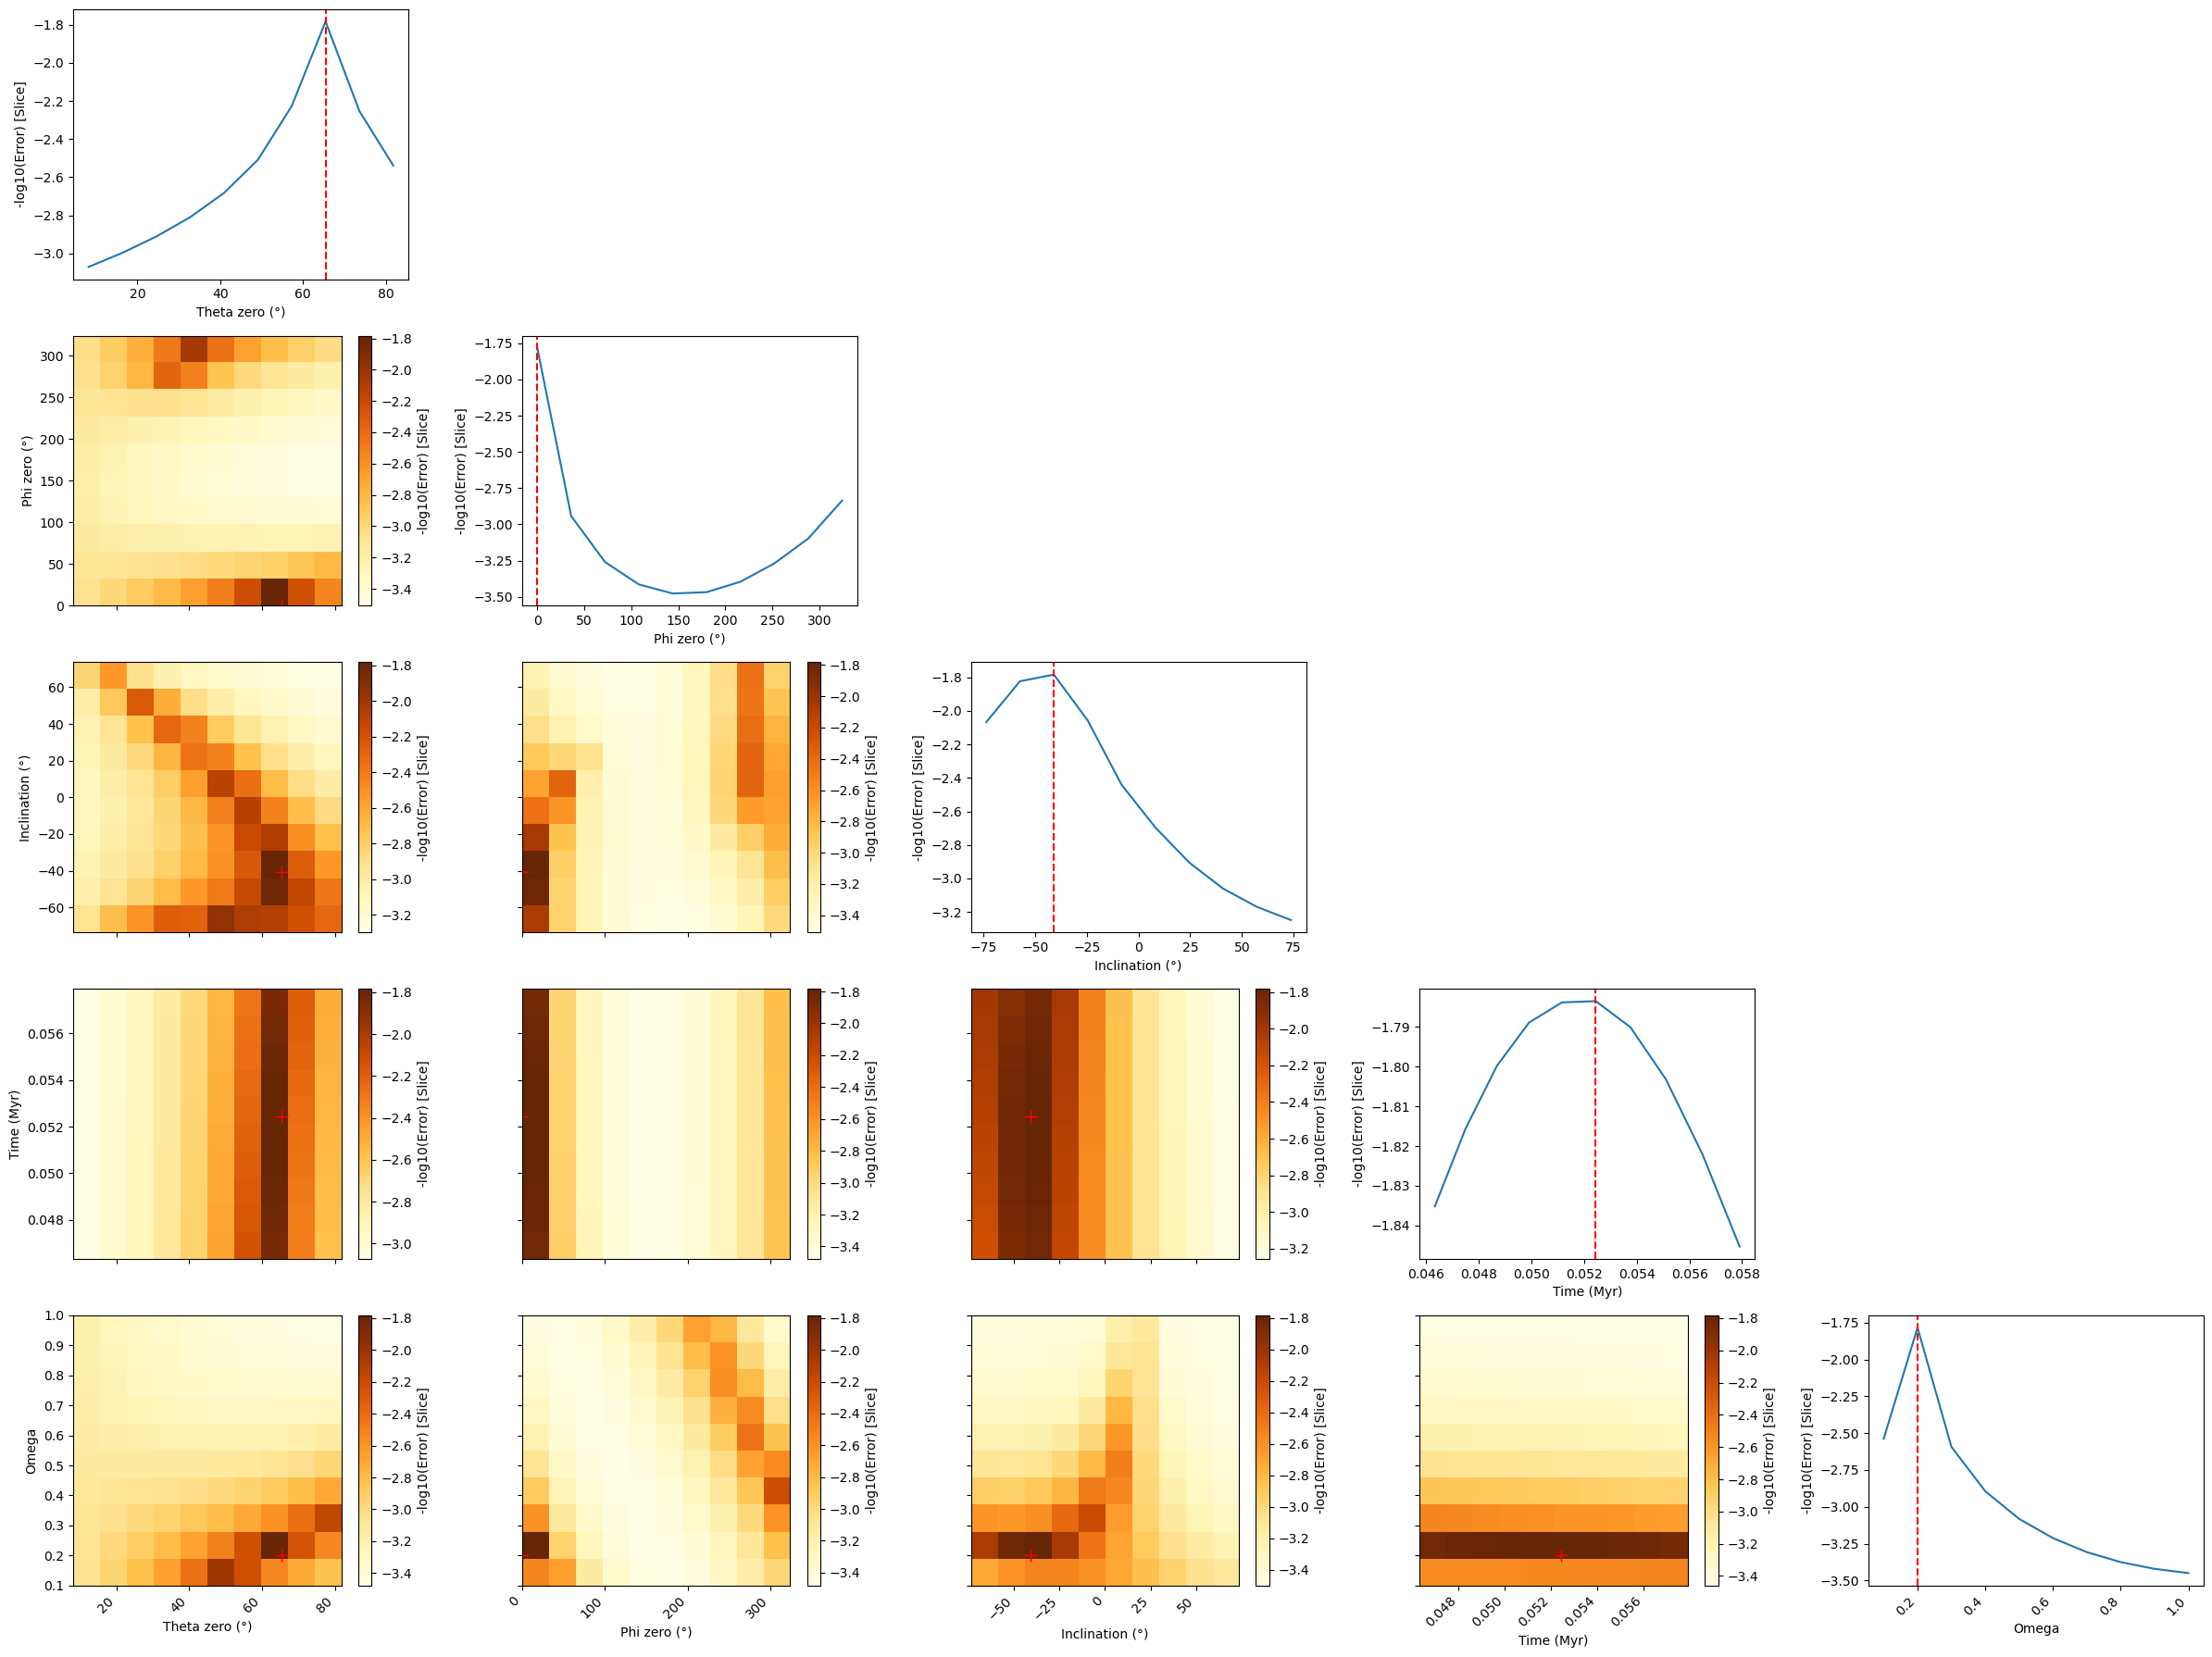

繪圖完成。
正在 'initial_guess' 附近建立一個緊密的初始採樣球...
開始運行 MCMC (使用快速的 error_function)...


100%|██████████| 15000/15000 [05:16<00:00, 47.39it/s]

MCMC 運行完畢。


In [ ]:
# -----------------------------------------------------------------------
# 動態設定 MCMC 的參數範圍 (已加入邊界檢查)
# -----------------------------------------------------------------------
parameter_prior_ranges = {
    'Theta zero': (Theta_init - np.deg2rad(15), Theta_init + np.deg2rad(15)),
    'Phi zero':   (Phi_init   - np.deg2rad(30), Phi_init   + np.deg2rad(30)),
    'Inclination':(Inclination_init - np.deg2rad(20), Inclination_init + np.deg2rad(20)),
    'Time':       (T_init * 0.8, T_init * 1.2),
    'Omega':      (Omega_init * 0.7, min(Omega_init * 1.3, 1.0))
}

# 打印新的範圍以供檢查
print("MCMC 參數的新範圍:")
for param, (min_val, max_val) in parameter_prior_ranges.items():
    if param in ["Theta zero", "Phi zero", "Inclination"]:
        print(f"{param:<12s}: ({np.rad2deg(min_val):.2f}, {np.rad2deg(max_val):.2f}) deg")
    elif param == 'Time':
        print(f"{param:<12s}: ({min_val:.4f}, {max_val:.4f}) Myr")
    else:
        print(f"{param:<12s}: ({min_val:.2f}, {max_val:.2f})")
        
# 1. 將 Error 轉換為 -log10(Error)
print("正在將 Error 轉換為 -log10(Error)...")
log_error = -np.log10(error) # "分數" 越高越好
labels = ["Theta zero", "Phi zero", "Inclination", "Time", "Omega"]
param_arrays = [theta, phi, Inclination, T_Myr, omega]

# 2. 找到 "分數" 最高的 (即 Error 最小的) 點的索引
best_fit_index_flat = np.argmax(log_error)
best_fit_indices = np.unravel_index(best_fit_index_flat, log_error.shape)

# 將 5D 索引解包
i_th_best, i_ph_best, i_I_best, i_T_best, i_O_best = best_fit_indices
best_indices_list = list(best_fit_indices) # 轉換為列表，方便後續修改

print(f"找到全局最佳解 (Minimum Error) 的索引位於:")
print(f"  Theta: {i_th_best}, Phi: {i_ph_best}, Incl: {i_I_best}, T: {i_T_best}, Omega: {i_O_best}")


# 3. 準備繪圖用的標籤和「轉換後」的參數陣列 (同上一版)
ndim = len(labels)
labels_for_plot = []
param_arrays_for_plot = []
angle_indices = [0, 1, 2] # 角度參數的索引
time_indices = [3]        # 時間參數的索引

for i in range(ndim):
    if i in angle_indices:
        labels_for_plot.append(labels[i] + " (°)")
        param_arrays_for_plot.append(np.rad2deg(param_arrays[i]))
    elif i in time_indices:
        labels_for_plot.append(labels[i] + " (Myr)")
        param_arrays_for_plot.append(param_arrays[i])
    else:
        labels_for_plot.append(labels[i])
        param_arrays_for_plot.append(param_arrays[i])

# 4. 建立 5x5 的子圖網格
fig, axs = plt.subplots(ndim, ndim, figsize=(24, 18), layout="tight")

print("正在繪製 5x5 最佳『切片』圖...")

# 遍歷所有子圖
for i in range(ndim):  # Y 軸 (row)
    for j in range(ndim):  # X 軸 (column)
        
        ax = axs[i, j]
        
        # 建立一個切片索引，預設為指向最佳點
        slice_idx = list(best_indices_list) # [i_th_best, i_ph_best, ...]

        if i == j:
            # --- 對角線 (i == j): 繪製 1D 切片 ---
            # 讓第 i 個維度變化，其他 4 個維度固定
            slice_idx[i] = slice(None) # slice(None) 代表選取整個軸
            
            data_1d = log_error[tuple(slice_idx)]
            
            ax.plot(param_arrays_for_plot[i], data_1d)
            ax.set_xlabel(labels_for_plot[i])
            ax.set_ylabel("-log10(Error) [Slice]")
            
            # 在最佳值上畫一條垂直線
            ax.axvline(param_arrays_for_plot[i][best_indices_list[i]], color='red', linestyle='--')


        elif i > j:
            # --- 下三角 (i > j): 繪製 2D 切片 ---
            # i = Y 軸, j = X 軸
            
            # 1. 讓第 i 和 j 維度變化，其他 3 個維度固定
            slice_idx[i] = slice(None) # Y 軸變化
            slice_idx[j] = slice(None) # X 軸變化
            
            # 2. 提取 2D 切片數據
            data_2d_raw = log_error[tuple(slice_idx)]
            data_2d_to_plot = data_2d_raw.T # 轉置以匹配 imshow
            
            # 3. 獲取座標軸範圍
            x_array = param_arrays_for_plot[j]
            y_array = param_arrays_for_plot[i]
            extent = [x_array.min(), x_array.max(), y_array.min(), y_array.max()]

            # 4. 繪製
            im = ax.imshow(data_2d_to_plot, origin='lower', aspect='auto', 
                           extent=extent, cmap='YlOrBr')
            
            cbar = fig.colorbar(im, ax=ax)
            cbar.set_label("-log10(Error) [Slice]")
            
            # 在 2D 圖上標出最佳點
            ax.plot(param_arrays_for_plot[j][best_indices_list[j]], 
                    param_arrays_for_plot[i][best_indices_list[i]], 
                    'r+', markersize=10) # 紅色十字

            # 5. 設置座標軸標籤
            if j == 0:
                ax.set_ylabel(labels_for_plot[i])
            else:
                ax.yaxis.set_major_formatter(plt.NullFormatter())
                
            if i == ndim - 1:
                ax.set_xlabel(labels_for_plot[j])
            else:
                ax.xaxis.set_major_formatter(plt.NullFormatter())

        else: 
            # --- 上三角 (i < j): 隱藏 ---
            ax.axis('off')

# 調整最下面一排的 X 軸標籤，防止重疊
for ax in axs[ndim-1, :]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.show()
print("繪圖完成。")

# --- 假設您在主腳本中定義了這些 ---
ndim = 5
nwalkers = 80   # 稍微多一點 walker（樣本多）
nsteps = 15000  # 時間允許的話多跑一點

# 您的觀測數據 (11 個質心點)
data_x = streamercom_x_AU
data_z = streamercom_z_AU
data_v = streamercom_v_LS_km

# 您的固定參數
prior_ranges = parameter_prior_ranges # 您的先驗範圍字典

# --- 建立傳遞給 MCMC 的參數包 (args) ---
# (順序必須與 log_posterior_fast 的參數完全一致)
mcmc_args = (
    prior_ranges,
    data_x,
    data_z,
    data_v,
    v_weight_phys,
    M_star,
    scale,
    log_power
)

# 建立初始位置 (initial_pos 保持不變)
# 1. 建立一個包含所有初始參數的陣列 (這是您的 "最佳猜測")
initial_guess = np.array([Theta_init, Phi_init, Inclination_init, T_init, Omega_init])

# 2. 建立一個 (nwalkers, ndim) 的陣列
initial_pos = np.zeros((nwalkers, ndim))

# 假設參數順序是 Theta0, Phi0, T, Incl, Omega
labels = ["Theta zero", "Phi zero", "Inclination", "Time", "Omega"]

print("正在 'initial_guess' 附近建立一個緊密的初始採樣球...")

for i in range(ndim):
    key = labels[i]
    guess_value = initial_guess[i]
    min_range, max_range = parameter_prior_ranges[key]

    # 改成範圍內隨機均勻分布（比高斯穩定）
    pos = np.random.uniform(min_range, max_range, nwalkers)
    initial_pos[:, i] = pos
    
moves = [
    (emcee.moves.StretchMove(a=2.5), 0.4),
    (emcee.moves.DEMove(), 0.6),
    # (emcee.moves.DESnookerMove(), 0.3)
]

sampler = emcee.EnsembleSampler(
    nwalkers, 
    ndim, 
    pss.log_posterior_fast,
    args=mcmc_args,
    moves=moves
)    

# 執行 MCMC
print("開始運行 MCMC (使用快速的 error_function)...")

sampler.run_mcmc(initial_pos, nsteps, progress=True)

print("MCMC 運行完畢。")

# 繪製 Corner Plot
samples_fast = sampler.get_chain(discard=1000, thin=50, flat=True)


In [40]:
# acc = np.mean(sampler.acceptance_fraction)
# print(f"acc={acc:.2f}")
# try:
#     tau = sampler.get_autocorr_time(tol=0)
#     print("tau:", tau)
# except Exception:
#     tau = None

[auto] tau=[32.79408679 34.76638576 33.83353969 34.31013615 32.95210125], burn-in=69, thin=16
flat_samples: (74640, 5) flat_lnprob: (74640,)
[MAP params]: [ 1.18688022  0.21188163 -1.04095758  0.04342123  0.1467131 ]
[Median params]: [ 1.13361765 -0.00458126 -0.70283536  0.05235808  0.19919138]
[Mean params]: [ 1.13683368 -0.0042573  -0.70670508  0.05238152  0.19929232]

[Best-fit params — 轉換後的單位]
Theta zero (°)  : 68.003227
Phi zero (°)    : 12.139923
Inclination (°) : -59.642476
Time (Myr)      : 0.043421
Omega           : 0.146713

[參數的中位數與68%區間]
Theta zero  : 64.951507 (+10.296063/-9.754258) deg
Phi zero    : -0.262487 (+18.150173/-18.197694) deg
Inclination : -40.269500 (+13.213352/-13.793496) deg
Time        : 0.052358 (+0.007142/-0.007073) Myr
Omega       : 0.199191 (+0.040899/-0.040624) 


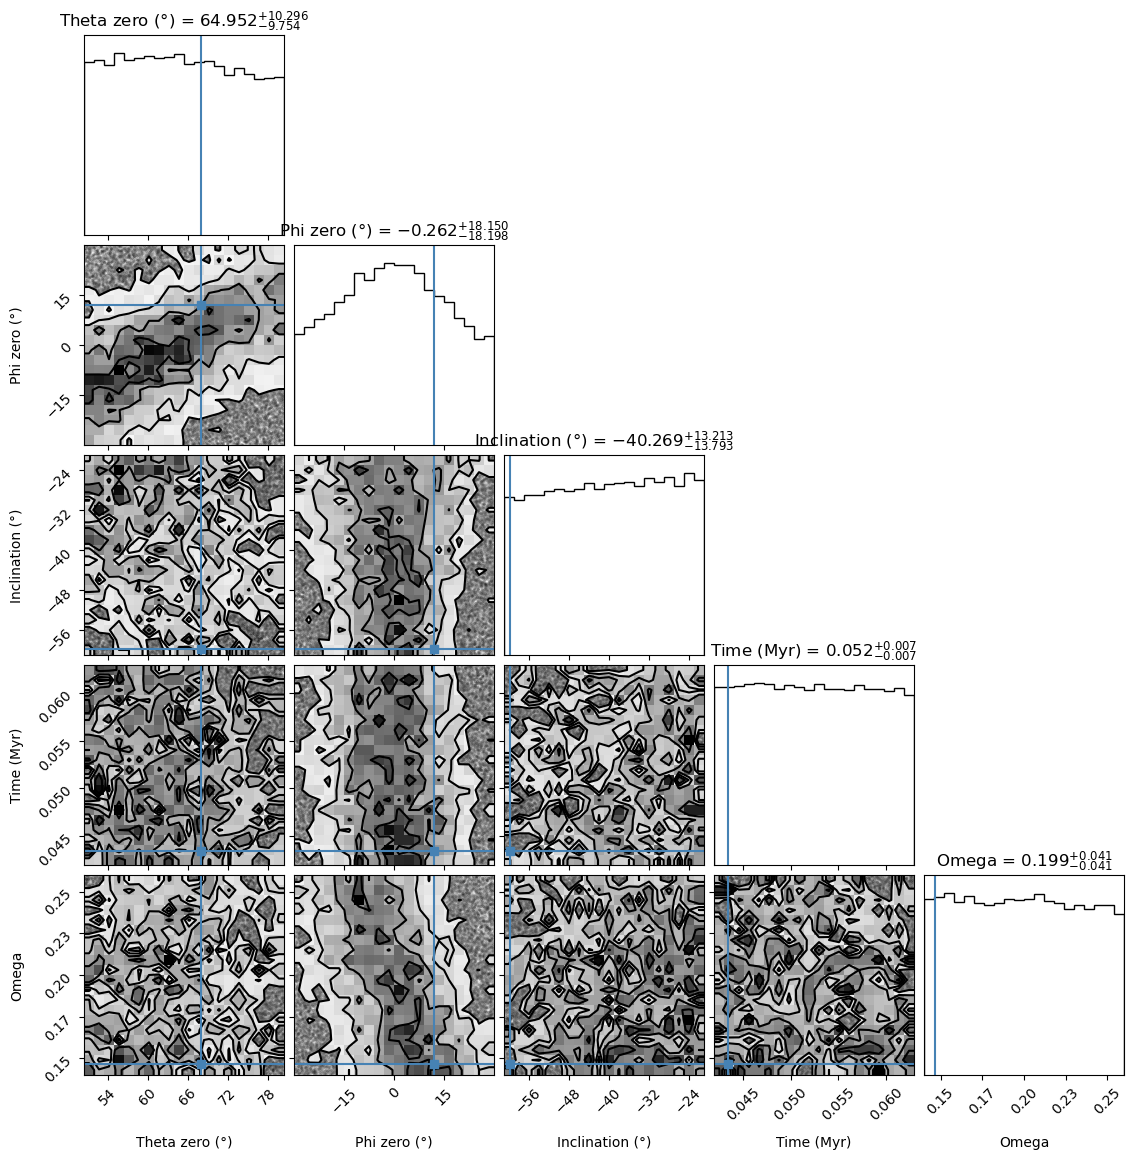


[MAP params]
Theta0 = 68.003 deg
Phi0   = 12.140 deg
Incl   = -59.642 deg
T      = 0.043421 Myr
Omega  = 0.146713


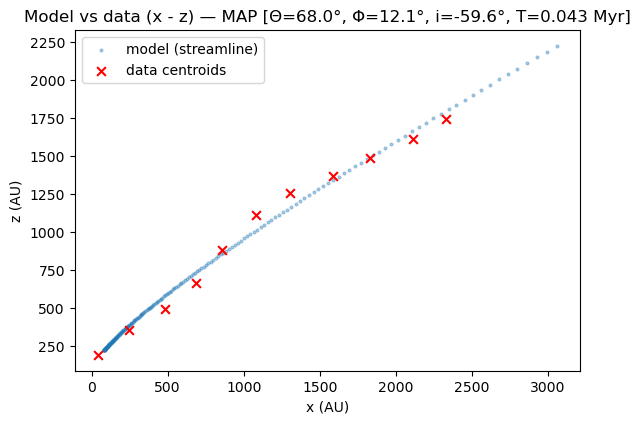

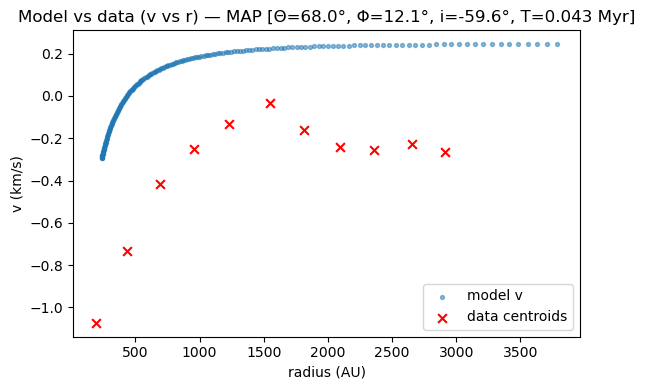

In [44]:
outdir = "mcmc_results"
os.makedirs(outdir, exist_ok=True)

# 1) 估計自相關時間；失敗就用保守預設
try:
    tau = sampler.get_autocorr_time(tol=0)
    burnin = int(2 * np.nanmax(tau))
    thin   = max(1, int(0.5 * np.nanmin(tau)))
    print(f"[auto] tau={tau}, burn-in={burnin}, thin={thin}")
except Exception as e:
    print("[auto] tau 估計失敗，用試跑的經驗值。", e)
    burnin, thin = 70, 16  # ← 來自你的試跑

# 2) 取樣展平
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
flat_lnprob  = sampler.get_log_prob(discard=burnin, thin=thin, flat=True)
print("flat_samples:", flat_samples.shape, "flat_lnprob:", flat_lnprob.shape)

# --- MAP ---
imax = np.argmax(flat_lnprob)
best_map = flat_samples[imax].copy()

# --- 中位數 ---
best_med = np.median(flat_samples, axis=0)

# --- 平均值（可選） ---
best_mean = np.mean(flat_samples, axis=0)

print("[MAP params]:", best_map)
print("[Median params]:", best_med)
print("[Mean params]:", best_mean)

# ====== 單位轉換 ======
# 角度參數轉成度數
angle_indices = [0, 1, 2]  # Theta, Phi, Inclination
best_params_deg = best_map.copy()
for idx in angle_indices:
    best_params_deg[idx] = np.rad2deg(best_params_deg[idx])

# 對應標籤
labels_deg = ["Theta zero (°)", "Phi zero (°)", "Inclination (°)", "Time (Myr)", "Omega"]

print("\n[Best-fit params — 轉換後的單位]")
for i, name in enumerate(labels_deg):
    print(f"{name:16s}: {best_params_deg[i]:.6f}")

# 4) 也計算中央值與68%區間，供參考 (並轉單位)
q16, q50, q84 = np.percentile(flat_samples, [16, 50, 84], axis=0)

print("\n[參數的中位數與68%區間]")
for i, name in enumerate(["Theta zero","Phi zero","Inclination","Time","Omega"]):
    lo, md, hi = q16[i], q50[i], q84[i]

    if i in angle_indices:
        lo, md, hi = np.rad2deg([lo, md, hi])
        unit = "deg"
    elif i == 3:
        unit = "Myr"
    else:
        unit = ""

    print(f"{name:12s}: {md:.6f} (+{hi-md:.6f}/-{md-lo:.6f}) {unit}")

# ====== 1) 準備單位轉換後的樣本與 labels ======
# 假設：flat_samples shape=(N, 5) 對應 [Theta0, Phi0, Incl, T, Omega]
#       labels = ["Theta zero","Phi zero","Inclination","Time","Omega"]
angle_indices = [0, 1, 2]
time_index = 3
omega_index = 4

# 複製一份樣本，將角度由 rad → deg
samples_for_plot = np.array(flat_samples, copy=True)
for idx in angle_indices:
    samples_for_plot[:, idx] = np.rad2deg(samples_for_plot[:, idx])

# 建新的軸標籤（角度加 °，時間加 Myr）
new_labels = []
for i, lab in enumerate(["Theta zero","Phi zero","Inclination","Time","Omega"]):
    if i in angle_indices:
        new_labels.append(f"{lab} (°)")
    elif i == time_index:
        new_labels.append(f"{lab} (Myr)")
    else:
        new_labels.append(lab)  # Omega 保持不變

# ====== 2) 將 MAP 參數 (best_params) 也做相同單位轉換，給 corner truths ======
best_params_plot = best_map.copy()
for idx in angle_indices:
    best_params_plot[idx] = np.rad2deg(best_params_plot[idx])

# ====== 3) 畫 corner（用轉好單位的 samples_for_plot 與 truths） ======
fig = corner.corner(
    samples_for_plot,
    labels=new_labels,
    truths=best_params_plot,
    show_titles=True,
    title_fmt=".3f"
)

# 客製化 T、Omega 軸的數值格式（選配）
axes = np.array(fig.get_axes()).reshape(len(new_labels), len(new_labels))

# T 軸（第 time_index 維）
if len(new_labels) > time_index:
    ax_x_time = axes[len(new_labels)-1, time_index]  # 最底排、T 的 X 軸
    ax_y_time = axes[time_index, 0]                 # 最左列、T 的 Y 軸
    ax_x_time.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.3f}"))
    ax_y_time.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.3f}"))

# Omega 軸（第 omega_index 維）
if len(new_labels) > omega_index:
    ax_x_omega = axes[len(new_labels)-1, omega_index]
    ax_y_omega = axes[omega_index, 0]
    ax_x_omega.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax_y_omega.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

fig.savefig(os.path.join(outdir, "corner_auto.png"), dpi=180)
plt.show()

# ====== 4) 以人類可讀單位列印 MAP 參數 ======
Theta_b, Phi_b, Incl_b, T_b, Omega_b = best_map
print("\n[MAP params]")
print(f"Theta0 = {np.rad2deg(Theta_b):.3f} deg")
print(f"Phi0   = {np.rad2deg(Phi_b):.3f} deg")
print(f"Incl   = {np.rad2deg(Incl_b):.3f} deg")
print(f"T      = {T_b:.6f} Myr")
print(f"Omega  = {Omega_b:.6f}")

# ====== 5) 下面的 model vs data 不需要改單位（你已是 AU & km/s）
# 但若想在圖標題上標註 MAP 參數（角度用度，時間用 Myr），可加：
title_xz = (f"Model vs data (x - z) — MAP "
            f"[Θ={np.rad2deg(Theta_b):.1f}°, Φ={np.rad2deg(Phi_b):.1f}°, "
            f"i={np.rad2deg(Incl_b):.1f}°, T={T_b:.3f} Myr]")
title_vr = (f"Model vs data (v vs r) — MAP "
            f"[Θ={np.rad2deg(Theta_b):.1f}°, Φ={np.rad2deg(Phi_b):.1f}°, "
            f"i={np.rad2deg(Incl_b):.1f}°, T={T_b:.3f} Myr]")

# 6) 用 best-fit 樣本重建模型並與 11 個質心點比較
#    假設你已有以下變數：PSS_model(or pss.PSS_model), M_star, radius_in_au, radius_out_au, log_power,
#    以及資料 data_x, data_z (AU), data_v (km/s)
try:
    x_m, y_m, z_m, u_m, v_m, w_m = pss.PSS_model(
        Theta_b, Phi_b, Incl_b, T_b, Omega_b, M_star,
        radius_in_au=radius_in_au, radius_out_au=radius_out_au,
        resolution=200, scale='log', log_power=log_power
    )

    # --- x-z 幾何比較 ---
    plt.figure(figsize=(6,6))
    plt.scatter(x_m, z_m, s=4, alpha=0.35, label="model (streamline)")
    plt.scatter(np.asarray(data_x), np.asarray(data_z), c='r', s=40, marker='x', label="data centroids")
    plt.xlabel("x (AU)"); plt.ylabel("z (AU)")
    plt.title(title_xz)
    plt.gca().set_aspect('equal', 'box'); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(outdir, "model_vs_data_xz_bestfit.png"), dpi=180)
    plt.show()

    # --- v vs radius 比較 ---
    r_model = np.sqrt(x_m**2 + z_m**2)
    r_data  = np.sqrt(np.asarray(data_x)**2 + np.asarray(data_z)**2)

    plt.figure(figsize=(6,4))
    plt.scatter(r_model, v_m, s=8, alpha=0.5, label="model v")
    plt.scatter(r_data, np.asarray(data_v), c='r', s=40, marker='x', label="data centroids")
    plt.xlabel("radius (AU)"); plt.ylabel("v (km/s)")
    plt.title(title_vr)
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(outdir, "model_vs_data_v_radius_bestfit.png"), dpi=180)
    plt.show()

except Exception as e:
    print("重建/繪圖失敗，請檢查 PSS_model 與變數命名是否一致：", e)


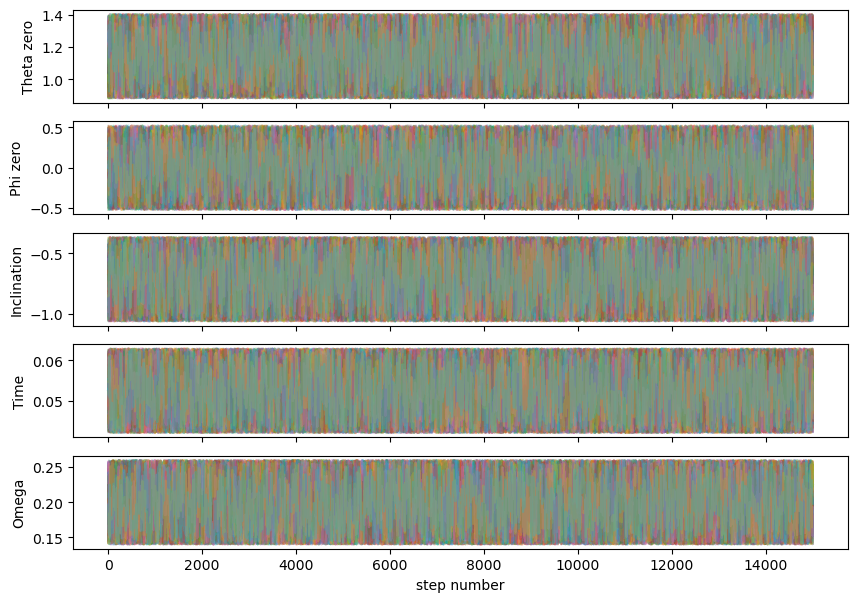

In [37]:
# Trace plot (觀察每個參數的穩定性)
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    axes[i].plot(sampler.get_chain()[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel("step number")
plt.show()


[MAP params]
Theta0 = 64.845 deg
Phi0   = -0.356 deg
Incl   = -40.265 deg
T      = 0.052281 Myr
Omega  = 0.199034


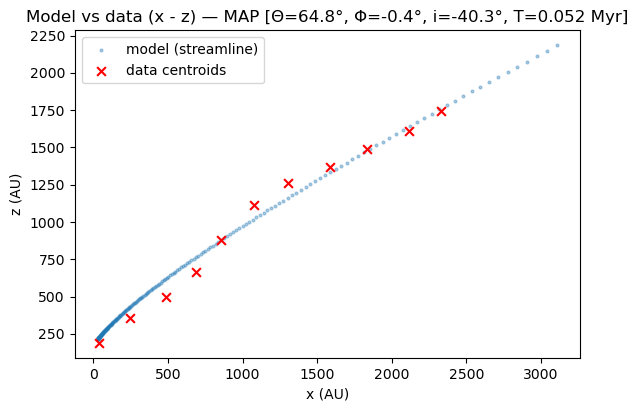

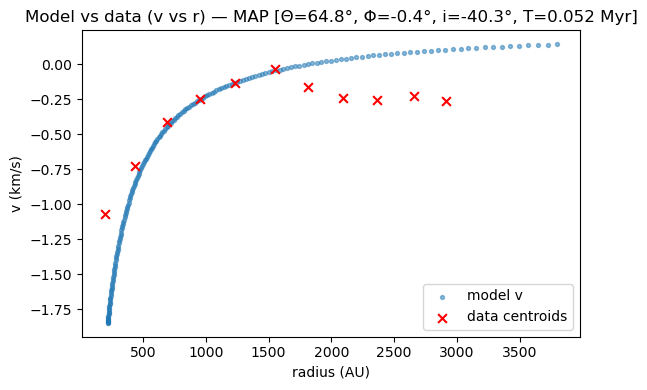

In [38]:
median_params = q50  # 這個是你算過的中位數陣列
Theta_med, Phi_med, Incl_med, T_med, Omega_med = median_params

x_m, y_m, z_m, u_m, v_m, w_m = pss.PSS_model(
    Theta_med, Phi_med, Incl_med, T_med, Omega_med, M_star,
    radius_in_au=radius_in_au, radius_out_au=radius_out_au,
    resolution=200, scale='log', log_power=log_power
)
# ====== 4) 以人類可讀單位列印 MAP 參數 ======
print("\n[MAP params]")
print(f"Theta0 = {np.rad2deg(Theta_med):.3f} deg")
print(f"Phi0   = {np.rad2deg(Phi_med):.3f} deg")
print(f"Incl   = {np.rad2deg(Incl_med):.3f} deg")
print(f"T      = {T_med:.6f} Myr")
print(f"Omega  = {Omega_med:.6f}")

# ====== 5) 下面的 model vs data 不需要改單位（你已是 AU & km/s）
# 但若想在圖標題上標註 MAP 參數（角度用度，時間用 Myr），可加：
title_xz = (f"Model vs data (x - z) — MAP "
            f"[Θ={np.rad2deg(Theta_med):.1f}°, Φ={np.rad2deg(Phi_med):.1f}°, "
            f"i={np.rad2deg(Incl_med):.1f}°, T={T_med:.3f} Myr]")
title_vr = (f"Model vs data (v vs r) — MAP "
            f"[Θ={np.rad2deg(Theta_med):.1f}°, Φ={np.rad2deg(Phi_med):.1f}°, "
            f"i={np.rad2deg(Incl_med):.1f}°, T={T_med:.3f} Myr]")

# 6) 用 best-fit 樣本重建模型並與 11 個質心點比較
#    假設你已有以下變數：PSS_model(or pss.PSS_model), M_star, radius_in_au, radius_out_au, log_power,
#    以及資料 data_x, data_z (AU), data_v (km/s)
try:
    x_m, y_m, z_m, u_m, v_m, w_m = pss.PSS_model(
        Theta_med, Phi_med, Incl_med, T_med, Omega_med, M_star,
        radius_in_au=radius_in_au, radius_out_au=radius_out_au,
        resolution=200, scale='log', log_power=log_power
    )

    # --- x-z 幾何比較 ---
    plt.figure(figsize=(6,6))
    plt.scatter(x_m, z_m, s=4, alpha=0.35, label="model (streamline)")
    plt.scatter(np.asarray(data_x), np.asarray(data_z), c='r', s=40, marker='x', label="data centroids")
    plt.xlabel("x (AU)"); plt.ylabel("z (AU)")
    plt.title(title_xz)
    plt.gca().set_aspect('equal', 'box'); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(outdir, "model_vs_data_xz_bestfit.png"), dpi=180)
    plt.show()

    # --- v vs radius 比較 ---
    r_model = np.sqrt(x_m**2 + z_m**2)
    r_data  = np.sqrt(np.asarray(data_x)**2 + np.asarray(data_z)**2)

    plt.figure(figsize=(6,4))
    plt.scatter(r_model, v_m, s=8, alpha=0.5, label="model v")
    plt.scatter(r_data, np.asarray(data_v), c='r', s=40, marker='x', label="data centroids")
    plt.xlabel("radius (AU)"); plt.ylabel("v (km/s)")
    plt.title(title_vr)
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(outdir, "model_vs_data_v_radius_bestfit.png"), dpi=180)
    plt.show()

except Exception as e:
    print("重建/繪圖失敗，請檢查 PSS_model 與變數命名是否一致：", e)

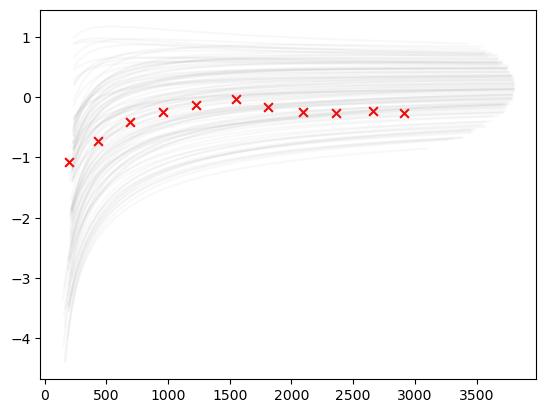

In [39]:
idx = np.random.choice(len(flat_samples), 100, replace=False)
for k in idx:
    th, ph, inc, T_, omg = flat_samples[k]
    x_m, _, z_m, _, v_m, _ = pss.PSS_model(
        th, ph, inc, T_, omg, M_star,
        radius_in_au=radius_in_au, radius_out_au=radius_out_au,
        resolution=200, scale='log', log_power=log_power
    )
    r_m = np.sqrt(x_m**2 + z_m**2)
    plt.plot(r_m, v_m, alpha=0.05, color='gray')
plt.scatter(r_data, np.asarray(data_v), c='r', s=40, marker='x', label="data centroids")

# 再把 data 用紅點疊上去

開始三參數 MCMC (Theta, Phi, Incl) with wide priors ...


100%|██████████| 8000/8000 [02:15<00:00, 59.14it/s]


三參數 MCMC 完成。
[3D] tau=[22.59263339 26.12766325 22.86822312], burn-in=52, thin=11


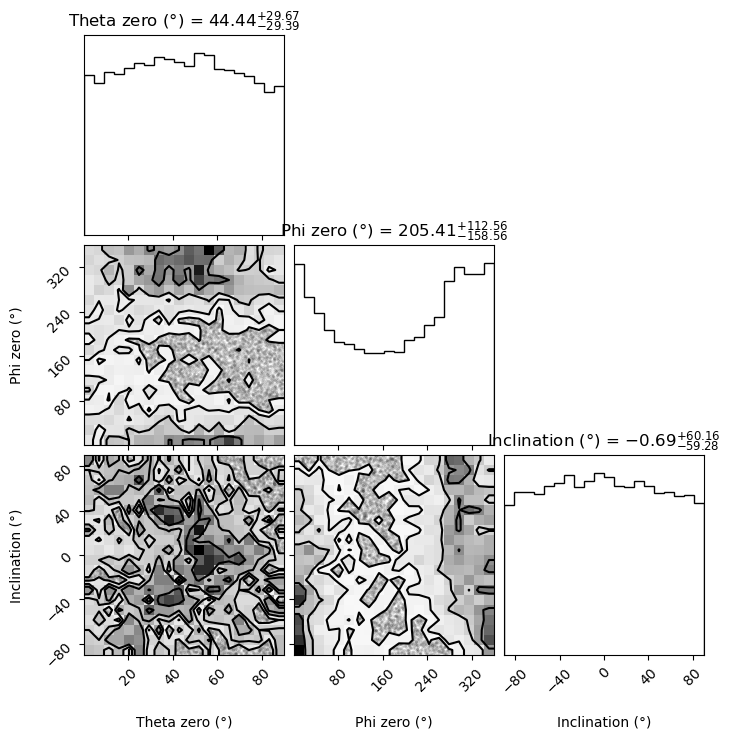


[3D MCMC 中位數與68%區間]
Theta zero (°)  :  44.440 (+29.674 / -29.387) deg
Phi zero (°)    : 205.408 (+112.558 / -158.559) deg
Inclination (°) :  -0.687 (+60.160 / -59.280) deg


In [42]:
def log_prior_3d(params, prior_ranges_3d):
    theta, phi, incl = params
    if not (prior_ranges_3d["Theta zero"][0] <= theta <= prior_ranges_3d["Theta zero"][1] and
            prior_ranges_3d["Phi zero"][0]   <= phi   <= prior_ranges_3d["Phi zero"][1] and
            prior_ranges_3d["Inclination"][0] <= incl <= prior_ranges_3d["Inclination"][1]):
        return -np.inf
    return 0.0

def log_posterior_3d(params,
                     prior_ranges_3d,
                     streamercom_x, streamercom_z, streamercom_v,
                     weight_v,
                     solar_mass,
                     T_Myr_fixed, omega_fixed,
                     scale, log_power):
    # uniform priors
    lp = log_prior_3d(params, prior_ranges_3d)
    if not np.isfinite(lp):
        return -np.inf

    theta, phi, incl = params

    rmse = pss.error_function(
        [theta, phi],
        streamercom_x,
        streamercom_z,
        streamercom_v,
        weight_v,
        T_Myr_fixed,
        omega_fixed,
        incl,
        solar_mass,
        scale,
        log_power
    )

    if rmse <= 0 or np.isnan(rmse):
        return -np.inf

    # 一樣用 -log10(RMSE) 當 log-likelihood
    return lp - np.log10(rmse)

# 使用和原本 grid 一樣寬的範圍，讓 corner plot 看起來是「大盒子裡的中心收縮」
prior_ranges_3d = {
    "Theta zero": (0.0, 0.5 * np.pi),          # 0 - 90 deg
    "Phi zero":   (0.0, 2.0 * np.pi),          # 0 - 360 deg
    "Inclination":(-0.5 * np.pi, 0.5 * np.pi)  # -90 - 90 deg
}

ndim_3d = 3
nwalkers_3d = 48
nsteps_3d = 8000

# 固定時間與 Omega 用目前 grid-search 最佳值
T_fixed = T_init
Omega_fixed = Omega_init

mcmc_args_3d = (
    prior_ranges_3d,
    streamercom_x_AU,
    streamercom_z_AU,
    streamercom_v_LS_km,
    v_weight_phys,
    M_star,
    T_fixed,
    Omega_fixed,
    scale,
    log_power
)

# 在 grid 最佳解附近撒一圈初始 walker
initial_guess_3d = np.array([Theta_init, Phi_init, Inclination_init])
p0_3d = np.zeros((nwalkers_3d, ndim_3d))
jitter_deg = np.array([20.0, 40.0, 30.0])  # 初始擾動尺度 (deg)

for i, key in enumerate(["Theta zero", "Phi zero", "Inclination"]):
    lo, hi = prior_ranges_3d[key]
    # 高斯微擾後再裁切到大範圍內
    if i < 3:
        span_rad = np.deg2rad(jitter_deg[i])
        p = initial_guess_3d[i] + span_rad * np.random.randn(nwalkers_3d)
    else:
        p = initial_guess_3d[i] + 0.05 * np.random.randn(nwalkers_3d)
    p = np.clip(p, lo, hi)
    p0_3d[:, i] = p

moves_3d = [
    (emcee.moves.StretchMove(a=2.5), 0.5),
    (emcee.moves.DEMove(),           0.5),
]

print("開始三參數 MCMC (Theta, Phi, Incl) with wide priors ...")
sampler_3d = emcee.EnsembleSampler(
    nwalkers_3d,
    ndim_3d,
    log_posterior_3d,
    args=mcmc_args_3d,
    moves=moves_3d
)
sampler_3d.run_mcmc(p0_3d, nsteps_3d, progress=True)
print("三參數 MCMC 完成。")

# 三參數鏈的自動 burn-in / thin
try:
    tau_3d = sampler_3d.get_autocorr_time(tol=0)
    burnin_3d = int(2 * np.max(tau_3d))
    thin_3d   = max(1, int(0.5 * np.min(tau_3d)))
    print(f"[3D] tau={tau_3d}, burn-in={burnin_3d}, thin={thin_3d}")
except Exception as e:
    print("[3D] tau 估計失敗，使用預設 burn-in/thin。", e)
    burnin_3d, thin_3d = 1000, 20

flat_3d = sampler_3d.get_chain(discard=burnin_3d, thin=thin_3d, flat=True)

# 轉成角度畫 corner，看看在大範圍先驗中 posterior 是否集中
samples_3d_plot = flat_3d.copy()
samples_3d_plot[:, 0] = np.rad2deg(samples_3d_plot[:, 0])
samples_3d_plot[:, 1] = np.rad2deg(samples_3d_plot[:, 1])
samples_3d_plot[:, 2] = np.rad2deg(samples_3d_plot[:, 2])

labels_3d = ["Theta zero (°)", "Phi zero (°)", "Inclination (°)"]

fig_3d = corner.corner(
    samples_3d_plot,
    labels=labels_3d,
    show_titles=True,
    title_fmt=".2f"
)
plt.show()

# 列出 3D MCMC 的中位數解，供檢查
q16_3d, q50_3d, q84_3d = np.percentile(flat_3d, [16, 50, 84], axis=0)
print("\n[3D MCMC 中位數與68%區間]")
for i, name in enumerate(labels_3d):
    lo, md, hi = q16_3d[i], q50_3d[i], q84_3d[i]
    lo_deg, md_deg, hi_deg = np.rad2deg([lo, md, hi])
    print(f"{name:<16s}: {md_deg:7.3f} (+{hi_deg-md_deg:6.3f} / -{md_deg-lo_deg:6.3f}) deg")

In [9]:
import time
def score_moves(moves, initial_pos, nsteps_pilot=2000):
    """回傳 {'acc':..., 'tau': array, 'ess':..., 'ess_per_sec':...}"""
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, pss.log_posterior_fast, args=mcmc_args, moves=moves
    )
    t0 = time.time()
    sampler.run_mcmc(initial_pos, nsteps_pilot, progress=False)
    dt = time.time() - t0

    acc = np.mean(sampler.acceptance_fraction)
    try:
        tau = sampler.get_autocorr_time(tol=0)  # shape=(ndim,)
        tau = np.asarray(tau)
        ess_per_dim = (nwalkers * (nsteps_pilot - int(2*np.nanmax(tau)))) / (2.0 * tau)
        ess = float(np.nansum(ess_per_dim))
    except Exception:
        tau = np.full(ndim, np.nan)
        ess = np.nan

    return {
        "acc": acc, "tau": tau, "ess": ess,
        "ess_per_sec": ess / dt if np.isfinite(ess) else np.nan,
        "time_sec": dt
    }

# 範例：掃三種組合
candidate_moves = {
    "balanced_343": [
        (emcee.moves.StretchMove(a=2.5), 0.3),
        (emcee.moves.DEMove(),           0.4),
        (emcee.moves.DESnookerMove(),    0.3),
    ],
    "stretch_heavy": [
        (emcee.moves.StretchMove(a=3.0), 0.6),
        (emcee.moves.DEMove(),           0.3),
        (emcee.moves.DESnookerMove(),    0.1),
    ],
    "de_snooker": [
        (emcee.moves.StretchMove(a=2.0), 0.2),
        (emcee.moves.DEMove(),           0.5),
        (emcee.moves.DESnookerMove(),    0.3),
    ],
}

print("\n[試跑 moves 組合，選 ESS/秒 最大者]")
scores = {}
for name, mv in candidate_moves.items():
    # 為公平性，給每個組合一個相同的初始位置拷貝
    s = score_moves(mv, initial_pos.copy(), nsteps_pilot=2000)
    scores[name] = s
    print(f"{name:14s}  acc={s['acc']:.3f}  ESS={s['ess']:.1f}  ESS/s={s['ess_per_sec']:.1f}  time={s['time_sec']:.1f}s")

# 選最好的一組
best_name = max(scores, key=lambda k: (scores[k]['ess_per_sec'], scores[k]['acc']))
best_moves = candidate_moves[best_name]
print(f"\n→ 採用：{best_name}  (以 ESS/秒 最大)")


[試跑 moves 組合，選 ESS/秒 最大者]
balanced_343    acc=0.294  ESS=11756.9  ESS/s=288.6  time=40.7s
stretch_heavy   acc=0.233  ESS=8890.0  ESS/s=225.8  time=39.4s
de_snooker      acc=0.310  ESS=13510.8  ESS/s=319.0  time=42.3s

→ 採用：de_snooker  (以 ESS/秒 最大)


[auto] tau=[32.33792104 34.39901365 32.3462657  32.79034163 32.30798642], burn-in=68, thin=16
flat_samples: (74640, 5) flat_lnprob: (74640,)
Best-fit (max log-posterior) params = Theta0=1.227395e+00, Phi0=2.341729e-01, Incl=-1.005946e+00, T=4.425901e-02, Omega=1.451943e-01


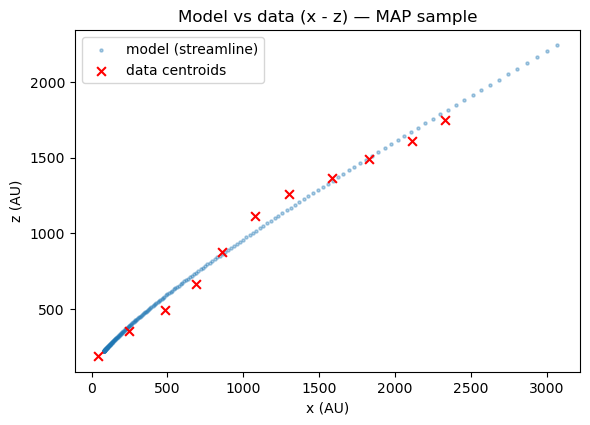

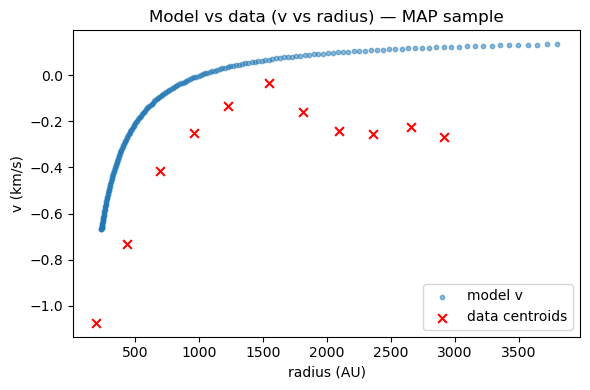

RMSE (geometry, AU) = 54.435
RMSE (velocity, km/s) = 0.325


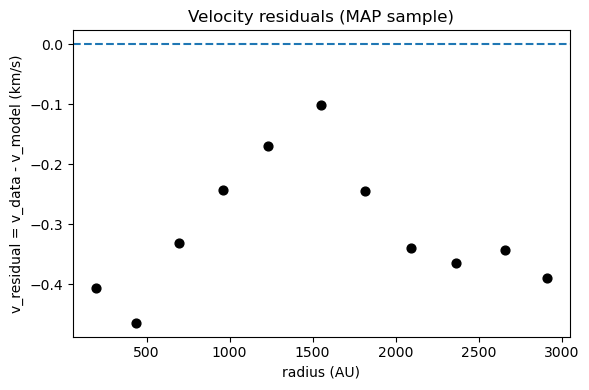

In [10]:
# 1) 自動估計 burn-in / thinning；失敗則用保守預設
try:
    tau = sampler.get_autocorr_time(tol=0)   # shape=(ndim,)
    tau = np.asarray(tau)
    burnin = int(2 * np.nanmax(tau))
    thin   = max(1, int(0.5 * np.nanmin(tau)))
    print(f"[auto] tau={tau}, burn-in={burnin}, thin={thin}")
except Exception as e:
    print("[auto] 無法估計自相關時間，使用保守預設。原因：", e)
    burnin = min(2000, int(0.2 * sampler.iteration))
    thin   = 50

# 2) 展平成 samples 與 log-posterior
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
flat_lnprob  = sampler.get_log_prob(discard=burnin, thin=thin, flat=True)
print("flat_samples:", flat_samples.shape, "flat_lnprob:", flat_lnprob.shape)

# 3) 取 log-posterior 最大（MAP 近似）
imax = int(np.argmax(flat_lnprob))
best_params = flat_samples[imax].copy()  # [Theta0, Phi0, Incl, T, Omega]
Theta_b, Phi_b, Incl_b, T_b, Omega_b = best_params
print("Best-fit (max log-posterior) params =",
      f"Theta0={Theta_b:.6e}, Phi0={Phi_b:.6e}, Incl={Incl_b:.6e}, T={T_b:.6e}, Omega={Omega_b:.6e}")

# 4) 用 best-fit 建模並繪圖
x_m, y_m, z_m, u_m, v_m, w_m = pss.PSS_model(
    Theta_b, Phi_b, Incl_b, T_b, Omega_b, M_star,
    radius_in_au=radius_in_au, radius_out_au=radius_out_au,
    resolution=200, scale='log', log_power=log_power
)

# --- 幾何：x-z 比較 ---
plt.figure(figsize=(6,6))
plt.scatter(x_m, z_m, s=5, alpha=0.35, label="model (streamline)")
plt.scatter(np.asarray(data_x), np.asarray(data_z), c='r', s=40, marker='x', label="data centroids")
plt.xlabel("x (AU)"); plt.ylabel("z (AU)")
plt.title("Model vs data (x - z) — MAP sample")
plt.gca().set_aspect('equal', 'box'); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, "model_vs_data_xz_MAP.png"), dpi=180)
plt.show()

# --- 速度：v vs radius 比較 ---
r_model = np.sqrt(x_m**2 + z_m**2)
r_data  = np.sqrt(np.asarray(data_x)**2 + np.asarray(data_z)**2)

plt.figure(figsize=(6,4))
plt.scatter(r_model, v_m, s=10, alpha=0.5, label="model v")
plt.scatter(r_data, np.asarray(data_v), c='r', s=40, marker='x', label="data centroids")
plt.xlabel("radius (AU)"); plt.ylabel("v (km/s)")
plt.title("Model vs data (v vs radius) — MAP sample")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, "model_vs_data_v_radius_MAP.png"), dpi=180)
plt.show()

# 5) 粗略 RMSE（以最近鄰配對到 model 曲線）
#   幾何 RMSE (AU) 與 速度 RMSE (km/s)
#   注意：這是簡單鄰近匹配，若要嚴謹可用你在 error_function 中那套距離定義。
from scipy.spatial import cKDTree

tree_geom = cKDTree(np.vstack([x_m, z_m]).T)
dist_geom, idx_geom = tree_geom.query(np.vstack([np.asarray(data_x), np.asarray(data_z)]).T, k=1)
rmse_geom = np.sqrt(np.mean(dist_geom**2))   # AU

# 對應最近 model 點的速度
v_model_at_data = v_m[idx_geom]
v_resid = np.asarray(data_v) - v_model_at_data
rmse_v = np.sqrt(np.mean(v_resid**2))        # km/s

print(f"RMSE (geometry, AU) = {rmse_geom:.3f}")
print(f"RMSE (velocity, km/s) = {rmse_v:.3f}")

# 6) 額外：殘差圖（v vs radius）
plt.figure(figsize=(6,4))
plt.axhline(0, ls='--')
plt.scatter(r_data, v_resid, c='k', s=40)
plt.xlabel("radius (AU)"); plt.ylabel("v_residual = v_data - v_model (km/s)")
plt.title("Velocity residuals (MAP sample)")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "velocity_residuals_MAP.png"), dpi=180)
plt.show()


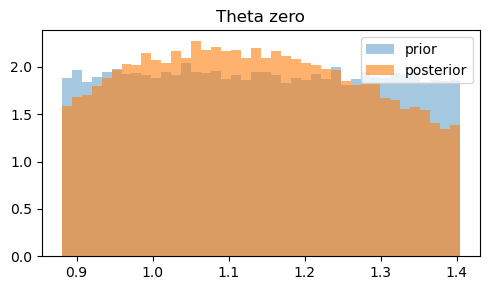

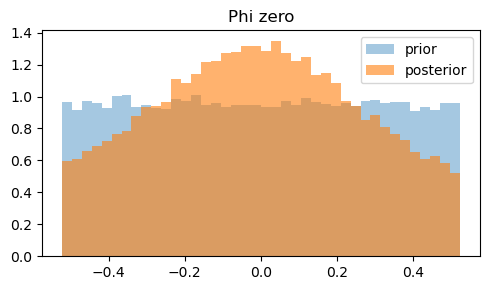

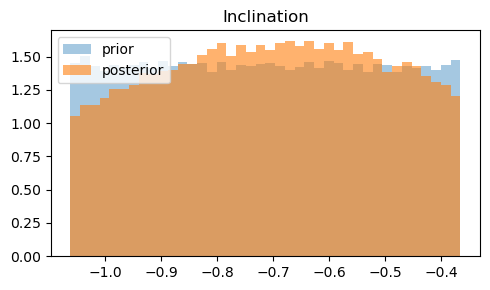

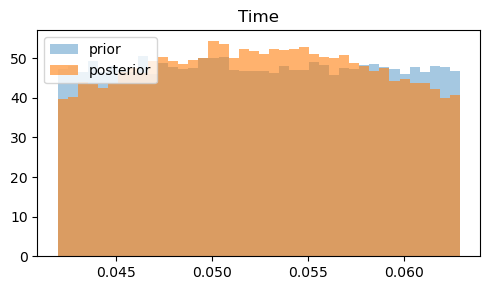

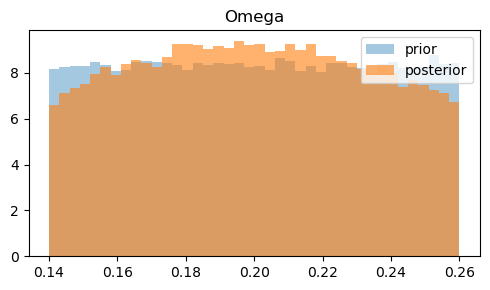

In [11]:
# 假設 flat_samples 是丟掉 burn-in 後的樣本
for j, name in enumerate(labels):
    post = flat_samples[:, j]
    # 產生一組 prior 抽樣（uniform/你的先驗）
    lo, hi = prior_ranges[name]
    prior_draw = np.random.uniform(lo, hi, size=post.size)

    plt.figure(figsize=(5,3))
    plt.hist(prior_draw, bins=40, density=True, alpha=0.4, label='prior')
    plt.hist(post,       bins=40, density=True, alpha=0.6, label='posterior')
    plt.title(name); plt.legend(); plt.tight_layout(); plt.show()


In [43]:


# outdir = "mcmc_results"
# os.makedirs(outdir, exist_ok=True)

# # 1) 取得 chains
# chain_all = sampler.get_chain()            # shape (nsteps, nwalkers, ndim)
# lnprob_all = sampler.get_log_prob()        # shape (nsteps, nwalkers)
# acceptance_fraction = sampler.acceptance_fraction  # length nwalkers

# print("Acceptance fraction (per walker) — mean:", np.mean(acceptance_fraction))
# print("Acceptance fraction (per walker) — median:", np.median(acceptance_fraction))

# # 2) Trace plot (每個參數 nwalkers 線條)
# fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.2*ndim), sharex=True)
# steps = chain_all.shape[0]
# for i in range(ndim):
#     ax = axes[i]
#     for w in range(chain_all.shape[1]):
#         ax.plot(chain_all[:, w, i], alpha=0.25, linewidth=0.7)
#     ax.set_ylabel(labels[i])
# axes[-1].set_xlabel("Step")
# plt.tight_layout()
# trace_path = os.path.join(outdir, "trace_plot.png")
# plt.savefig(trace_path, dpi=200)
# plt.show()

# # 3) Acceptance fraction histogram
# plt.figure(figsize=(6,3))
# plt.hist(acceptance_fraction, bins=20, range=(0,1))
# plt.xlabel("Acceptance fraction per walker")
# plt.ylabel("Count")
# plt.title("Walker acceptance fractions")
# plt.tight_layout()
# plt.savefig(os.path.join(outdir, "acceptance_fraction_hist.png"), dpi=150)
# plt.show()

# # 4) Autocorrelation time (if emcee supports)
# tau = None
# try:
#     tau = sampler.get_autocorr_time(tol=0)
#     print("Autocorr times:", tau)
#     # 建議 burn-in
#     recommended_burnin = int(2 * np.nanmax(tau))
#     print("Suggested burn-in (2 * max(tau)) =", recommended_burnin)
# except Exception as e:
#     print("Could not compute autocorr time automatically (maybe chain too short or non-converged).")
#     print("Exception:", e)

# # 5) Flatten samples with burn-in & thinning
# burnin = 1000  # 你可依上面 autcorr 結果調整
# thin = 50
# flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
# flat_lnprob = sampler.get_log_prob(discard=burnin, thin=thin, flat=True)

# print("Flat samples shape:", flat_samples.shape)
# np.save(os.path.join(outdir, "flat_samples.npy"), flat_samples)
# np.save(os.path.join(outdir, "flat_lnprob.npy"), flat_lnprob)

# # 6) Corner plot (含初始猜測(真值)標記)
# corner_fig = corner.corner(flat_samples, labels=labels, truths=initial_guess, show_titles=True, title_fmt=".4e")
# corner_fig_path = os.path.join(outdir, "corner.png")
# corner_fig.savefig(corner_fig_path, dpi=200)
# plt.show()

# # 7) 計算 median ± 16/84 percentile (約 ±1σ) 並輸出
# percentiles = np.percentile(flat_samples, [16, 50, 84], axis=0)
# lower_err = percentiles[1] - percentiles[0]
# upper_err = percentiles[2] - percentiles[1]
# median = percentiles[1]

# print("\n--- Posterior summary (median +1σ / -1σ) ---")
# for i, key in enumerate(labels):
#     print(f"{key:12s}: {median[i]:.6e} (+{upper_err[i]:.6e} / -{lower_err[i]:.6e})")

# # 儲存 summary 到文字檔
# with open(os.path.join(outdir, "posterior_summary.txt"), "w") as f:
#     f.write("--- Posterior summary (median +1σ / -1σ) ---\n")
#     for i, key in enumerate(labels):
#         f.write(f"{key:12s}: {median[i]:.6e} (+{upper_err[i]:.6e} / -{lower_err[i]:.6e})\n")

# # 8) 儲存整個 sampler (pickle)（注意：pickle 檔可能很大）
# sampler_file = os.path.join(outdir, "sampler_object.pkl")
# with open(sampler_file, "wb") as f:
#     pickle.dump(sampler, f, protocol=pickle.HIGHEST_PROTOCOL)
# print("Sampler saved to", sampler_file)

# # 9) 選出 "最佳參數"：使用 median (或你想用 MAP)
# best_params = median.copy()
# print("Best params (median):", best_params)

# # 10) 用最佳參數重建 model，並與你的 11 個質心點比較 (2 種視圖)
# # 注意：這裡假設你的 PSS_model 定義在全域或 pss.PSS_model 可呼叫，且回傳 (x,y,z,u,v,w) in AU / km/s
# try:
#     # 若 PSS_model 在 module pss，例如 pss.PSS_model:
#     pss_func = pss.PSS_model  # 若你的函數在名稱空間不同，請修改這一行
#     Theta_best, Phi_best, Incl_best, T_best, Omega_best = best_params

#     # 產生 model（調整 radius_in_au, radius_out_au, resolution 如需要）
#     x_m, y_m, z_m, u_m, v_m, w_m = pss_func(Theta_best, Phi_best, Incl_best, T_best, Omega_best, M_star,
#                                            radius_in_au=radius_in_au, radius_out_au=radius_out_au, resolution=100, scale='log', log_power=log_power)

#     # 轉成你使用的 pixel 或單位（如果你之前在 log_likelihood_fast 裡有轉換）
#     # 這裡先畫物理單位 (AU vs AU) 的 x-z 平面對比
#     plt.figure(figsize=(6,6))
#     plt.scatter(x_m, z_m, s=2, alpha=0.3, label="model (streamline)")
#     # overlay data centers
#     plt.scatter(data_x, data_z, c='r', s=40, marker='x', label="data centroids")
#     plt.xlabel("x (AU)")
#     plt.ylabel("z (AU)")
#     plt.legend()
#     plt.title("Model vs data (x - z)")
#     plt.gca().set_aspect('equal', 'box')
#     plt.tight_layout()
#     plt.savefig(os.path.join(outdir, "model_vs_data_xz.png"), dpi=200)
#     plt.show()

#     # velocity comparison: model v (km/s) vs projected radius or x
#     # 用 v_m (km/s) vs radius (AU)
#     r_model = np.sqrt(x_m**2 + z_m**2)
#     plt.figure(figsize=(6,4))
#     plt.scatter(r_model, v_m, s=6, alpha=0.4, label="model v")
#     # data v vs radius
#     r_data = np.sqrt(np.array(data_x)**2 + np.array(data_z)**2)
#     plt.scatter(r_data, data_v, c='r', s=40, marker='x', label="data centroids")
#     plt.xlabel("radius (AU)")
#     plt.ylabel("v (km/s)")
#     plt.legend()
#     plt.title("Model vs data (v vs radius)")
#     plt.tight_layout()
#     plt.savefig(os.path.join(outdir, "model_vs_data_v_radius.png"), dpi=200)
#     plt.show()

# except Exception as e:
#     print("在重新產生 model 或繪圖時發生例外，請確認 PSS_model 可呼叫，或變數命名是否一致。")
#     print("Exception:", e)

# print("All done. Files written to:", outdir)


In [44]:
# # 1. 取得 log-posterior (log_prob) trace
# log_prob_samples = sampler.get_log_prob()  # shape = (nsteps, nwalkers)

# # 2. 取得 acceptance fraction for each walker
# acceptance_fractions = sampler.acceptance_fraction

# # 3. 繪製 log-posterior trace（觀察是否收斂）
# plt.figure(figsize=(10, 5))
# for i in range(nwalkers):
#     plt.plot(log_prob_samples[:, i], alpha=0.3)
# plt.xlabel("Step")
# plt.ylabel("Log Posterior")
# plt.title("Log Posterior Trace")
# plt.show()

# # 4. 繪製 acceptance fraction 的分佈
# plt.figure(figsize=(6, 4))
# plt.hist(acceptance_fractions, bins=20, alpha=0.7, edgecolor='k')
# plt.xlabel("Acceptance Fraction")
# plt.ylabel("Number of Walkers")
# plt.title("Acceptance Fraction Distribution")
# plt.show()

# print(f"Mean acceptance rate: {np.mean(acceptance_fractions):.3f}")


In [40]:
# sampler.reset()
# acceptance_history = []

# for sample in sampler.run_mcmc(initial_pos, nsteps, progress=True):
#     acceptance_history.append(sampler.acceptance_fraction.copy())
# acceptance over time (每步平均)
# mean_acceptance_over_time = [np.mean(a) for a in acceptance_history]

# plt.figure(figsize=(8, 4))
# plt.plot(mean_acceptance_over_time)
# plt.xlabel("Step")
# plt.ylabel("Mean Acceptance")
# plt.title("Mean Acceptance Over Time")
# plt.show()


正在將 MCMC 採樣結果中的弧度轉換為角度...
正在為 T 和 Omega 參數的座標軸添加客製化格式...
繪圖完成。


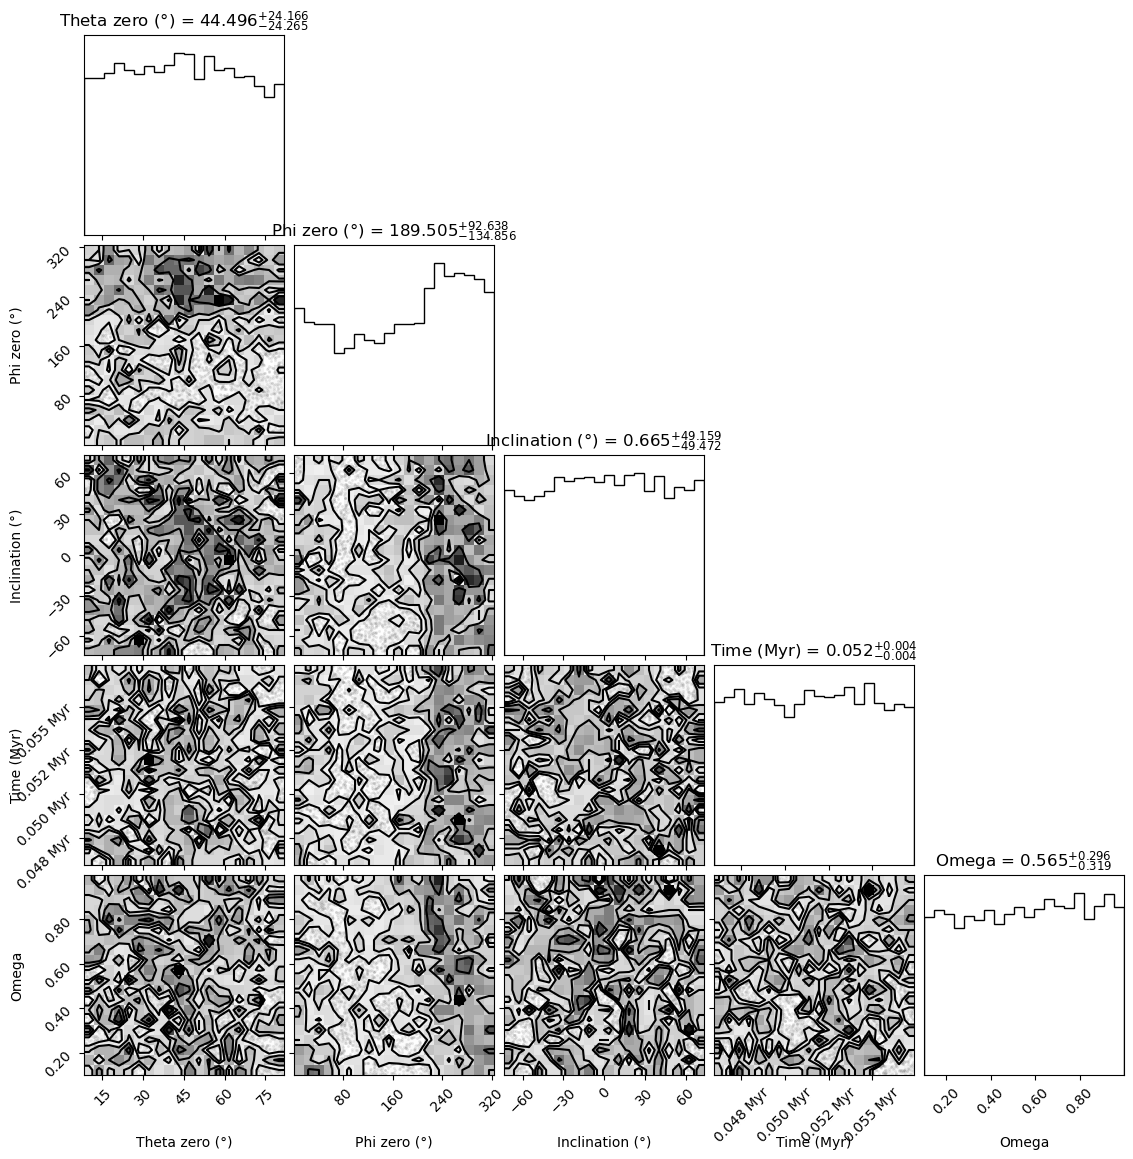

In [33]:

print("正在將 MCMC 採樣結果中的弧度轉換為角度...")
samples_for_plot = np.copy(samples_fast)
angle_indices = [0, 1, 2] # 角度參數的索引 ("Theta0", "Phi0", "Inclination")
time_index = 3
omega_index = 4 


for idx in angle_indices:
    samples_for_plot[:, idx] = np.rad2deg(samples_for_plot[:, idx])

# --- 2. 建立新的標籤 (為角度加上單位) ---
new_labels = []
for i, label in enumerate(labels):
    if i in angle_indices:
        new_labels.append(label + " (°)") # 例如 "Theta0 (°)"
    elif i == time_index:
        new_labels.append(label + " (Myr)") # "T (Myr)"
    else:
        new_labels.append(label) # "Omega" 保持不變

# --- 3. 繪製 Corner Plot ---
# 因為我們傳入的是 "samples_for_plot" (角度數據)，
# 所以 show_titles=True 會自動計算出「角度」的標題，
# 並且座標軸也會自動使用「角度」的刻度。
fig = corner.corner(
    samples_for_plot, 
    labels=new_labels, 
    show_titles=True,
    title_fmt='.3f' # 讓所有標題（包括 T）都顯示為小數點後 2 位
)

# --- 4. 後期處理：為 T 和 Omega 客製化軸標籤 (如您所願) ---
print("正在為 T 和 Omega 參數的座標軸添加客製化格式...")
axes = np.array(fig.get_axes()).reshape(ndim, ndim)

# T 的索引
if ndim > time_index:
    ax_x_time = axes[ndim-1, time_index] # T 的 X 軸
    ax_y_time = axes[time_index, 0]     # T 的 Y 軸
    
    # 應用您想要的 "Myr" 格式
    ax_x_time.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.3f} Myr'))
    ax_y_time.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.3f} Myr'))

# Omega 的索引
if ndim > omega_index:
    ax_x_omega = axes[ndim-1, omega_index] # Omega 的 X 軸
    ax_y_omega = axes[omega_index, 0]     # Omega 的 Y 軸
    
    # 應用您想要的 "%.2f" 格式
    ax_x_omega.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax_y_omega.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# 3. 最後顯示您修改過的「一張圖」
print("繪圖完成。")
plt.show()